## CAR PRICE PREDICTION

#  Car Price Prediction Dataset Overview

This dataset contains information about various car attributes and their prices. Our goal is to perform Exploratory Data Analysis (EDA) and build a model to predict car prices based on these features.

###  Data Description Table

| Column Name | Description |
| :--- | :--- |
| ID | Unique identifier for each car entry. |
| Price | The target variable representing the price of the car. |
| Levy | Tax amount applicable to the vehicle. |
| Manufacturer | The brand or company that produced the car (e.g., Toyota, BMW). |
| Model | The specific model name of the vehicle. |
| Prod. year | The year the car was manufactured. |
| Category | The type of car body (e.g., Sedan, Jeep, Hatchback). |
| Leather interior | Indicates if the car has a leather interior (Yes/No). |
| Fuel type | The type of fuel used by the engine (e.g., Petrol, Diesel, Hybrid). |
| Engine volume | The capacity of the engine (e.g., 2.0, 3.5). |
| Mileage | Total distance the car has traveled (in kilometers). |
| Cylinders | Number of cylinders in the car's engine. |
| Gear box type | Type of transmission (e.g., Automatic, Manual, Tiptronic). |
| Drive wheels | The drive system (e.g., Front, Rear, 4x4). |
| Doors | Number of doors on the vehicle. |
| Wheel | Steering wheel position (Left hand drive / Right hand drive). |
| Color | The exterior color of the car. |
| Airbags | Total number of airbags for safety. |

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/train_car_price.csv')
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15784,45730512,$44752,880,SSANGYONG,Actyon,2018,Jeep,Yes,Petrol,1.6,11953KM,4.0,Automatic,Front,04-May,Left wheel,Red,4,NaN
15785,45648818,$18817,609,TOYOTA,Camry,2018,Sedan,Yes,Hybrid,2.5,35058KM,4.0,Automatic,Front,04-May,Left wheel,White,12,NaN
15786,45648475,$16621,915,BMW,X5,2014,Jeep,Yes,Diesel,3,110715KM,6.0,Automatic,4x4,04-May,Left wheel,White,0,NaN
15787,45805255,$12544,-,BMW,325,2005,Sedan,Yes,Petrol,2.5,162000KM,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,12,NaN


In [126]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15789 entries, 0 to 15788
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                15789 non-null  int64  
 1   Price             15789 non-null  str    
 2   Levy              14421 non-null  str    
 3   Manufacturer      15789 non-null  str    
 4   Model             15789 non-null  str    
 5   Prod. year        15789 non-null  int64  
 6   Category          15789 non-null  str    
 7   Leather interior  15789 non-null  str    
 8   Fuel type         15789 non-null  str    
 9   Engine volume     15789 non-null  str    
 10  Mileage           14421 non-null  str    
 11  Cylinders         15789 non-null  float64
 12  Gear box type     15789 non-null  str    
 13  Drive wheels      15789 non-null  str    
 14  Doors             15789 non-null  str    
 15  Wheel             15789 non-null  str    
 16  Color             14421 non-null  str    
 17  Airb

# checking missing values

In [128]:
df.isna().sum()

ID                      0
Price                   0
Levy                 1368
Manufacturer            0
Model                   0
Prod. year              0
Category                0
Leather interior        0
Fuel type               0
Engine volume           0
Mileage              1368
Cylinders               0
Gear box type           0
Drive wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64

In [3]:
#drop the empty columns
df.drop(columns=['Random_notes'], inplace=True)

In [4]:
df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [5]:
df.describe()

,ID,Prod. year,Cylinders,Airbags
count,1.578900e+04,15789.000000,15789.000000,15789.000000
mean,4.557887e+07,2010.917031,4.582431,6.560580
std,9.347197e+05,5.699507,1.198396,4.315139
min,2.074688e+07,1939.000000,1.000000,0.000000
25%,4.570848e+07,2009.000000,4.000000,4.000000
50%,4.577252e+07,2012.000000,4.000000,6.000000
75%,4.580205e+07,2015.000000,4.000000,12.000000
max,4.581665e+07,2020.000000,16.000000,16.000000



###  Dataset Statistics Summary
Based on our initial data inspection (df.info()):
- Total Samples: 15,789 entries.
- Total Features: 19 columns.
- Data Types: A mix of numerical (int64, float64) and categorical (object) variables.
- Missing Data: One redundant column (Unnamed: 11 or Random_notes) was identified as fully empty and will be handled during preprocessing.

 # cheaking for duplicates

In [132]:
df.duplicated().sum()

np.int64(378)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

# converting the columns into the right type


In [8]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [9]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')
df['Mileage'] = df['Mileage'].str.replace(',', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

In [10]:
df['Engine volume'] = df['Engine volume'].str.extract('(\d+\.\d+)').astype(float)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Sameh\AppData\Local\Temp\ipykernel_11980\2236820397.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Engine volume'] = df['Engine volume'].str.extract('(\d+\.\d+)').astype(float)


In [11]:
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' Turbo', '').astype(float)

In [12]:
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' CHEVROLET', '').astype(float)

In [13]:
df['Levy'] = df['Levy'].replace('-', '0').astype(float)

In [14]:
print(df[['Mileage', 'Engine volume','Price' ,'Levy']].dtypes)

Mileage          float64
Engine volume    float64
Price              int64
Levy             float64
dtype: object


# seperating data types

In [15]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print(cat_cols)
print(num_cols)

Index(['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')
Index(['ID', 'Price', 'Levy', 'Prod. year', 'Engine volume', 'Mileage',
       'Cylinders', 'Airbags'],
      dtype='str')


C:\Users\Sameh\AppData\Local\Temp\ipykernel_11980\3451856678.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


# price distribution

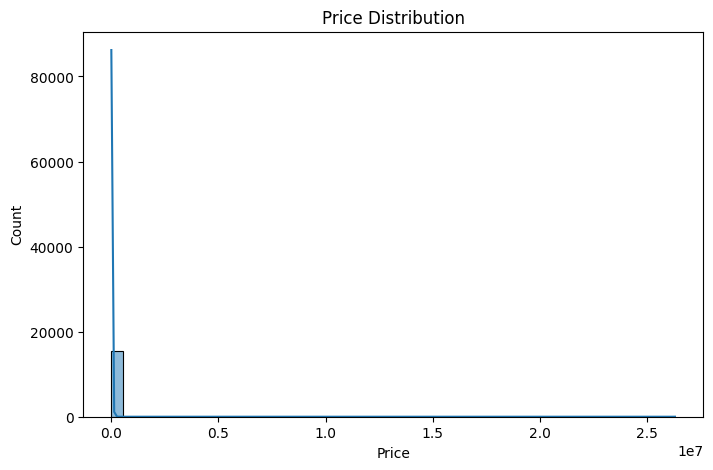

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

In [18]:
df['Price'].describe()

count    1.541100e+04
mean     1.889800e+04
std      2.127171e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.219850e+04
max      2.630750e+07
Name: Price, dtype: float64

In [19]:
df['Price'].sort_values(ascending=False).head(10)

10337    26307500
2194       872946
1673       627220
6928       308906
12354      297930
13759      260296
9207       254024
2807       250574
4604       228935
8912       219527
Name: Price, dtype: int64

# log Transformation

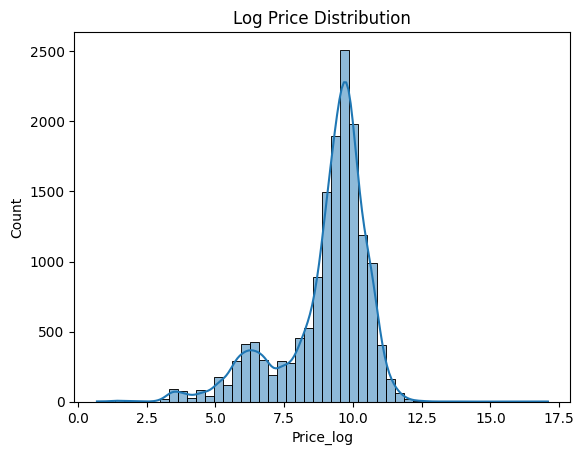

In [26]:
df['Price_log'] = np.log1p(df['Price'])

sns.histplot(df['Price_log'], bins=50, kde=True)
plt.title("Log Price Distribution")
plt.show()

#  checking outliers 

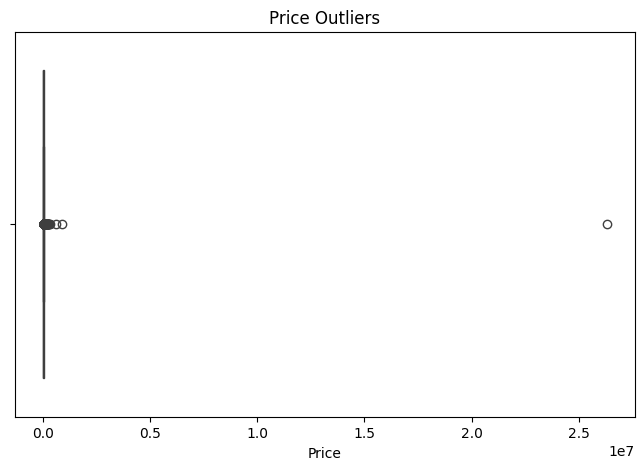

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [20]:
print(df['Price'].sort_values(ascending=False).head(10))
limit = df['Price'].quantile(0.99)
print(f"99% of cars are below: {limit}")

10337    26307500
2194       872946
1673       627220
6928       308906
12354      297930
13759      260296
9207       254024
2807       250574
4604       228935
8912       219527
Name: Price, dtype: int64
99% of cars are below: 84596.59999999971


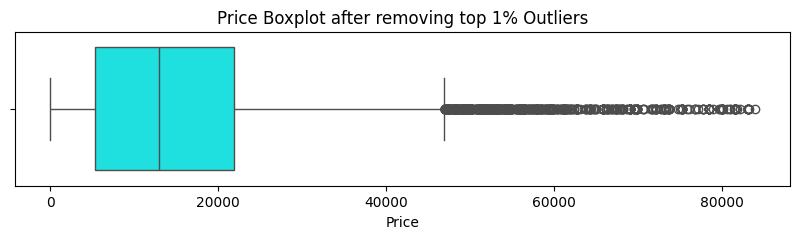

In [21]:
df = df[df['Price'] <= limit]
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Price'], color='cyan')
plt.title('Price Boxplot after removing top 1% Outliers')
plt.show()

# remove outliers

In [91]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

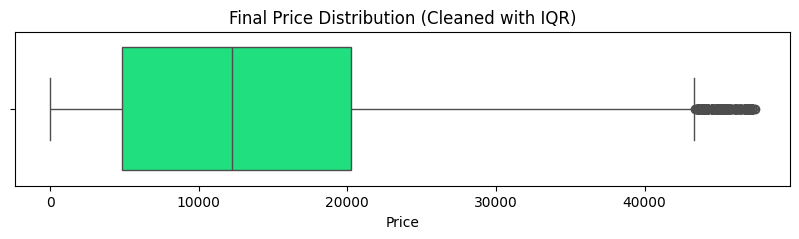

In [96]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Price'], color='springgreen')
plt.title('Final Price Distribution (Cleaned with IQR)')
plt.show()

# TOP Manufacturers

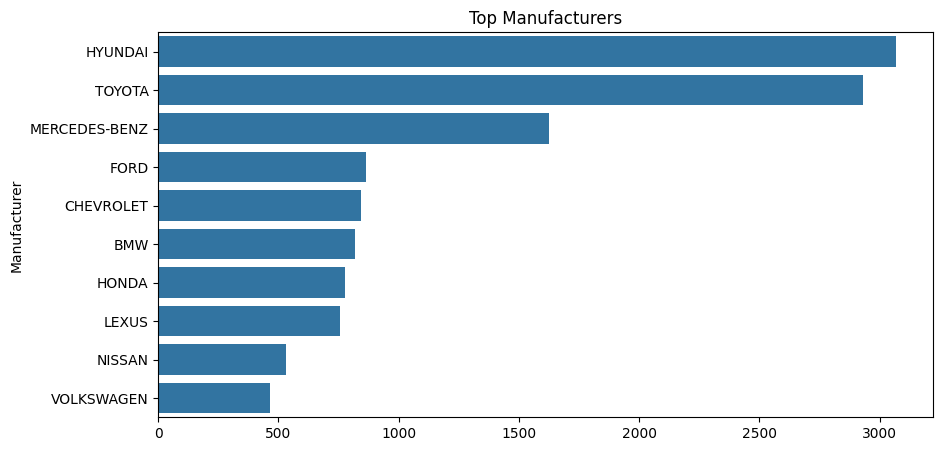

In [22]:
top=df['Manufacturer'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top.values, y=top.index)
plt.title("Top Manufacturers")
plt.show()

# Price vs year

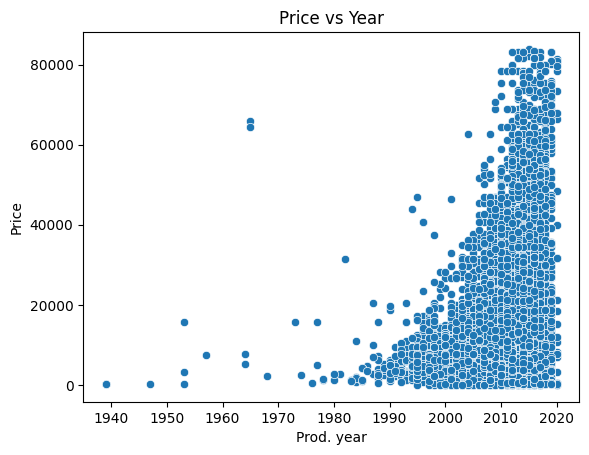

In [23]:
sns.scatterplot(x='Prod. year', y='Price', data=df)
plt.title("Price vs Year")
plt.show()

# Catogry vs price

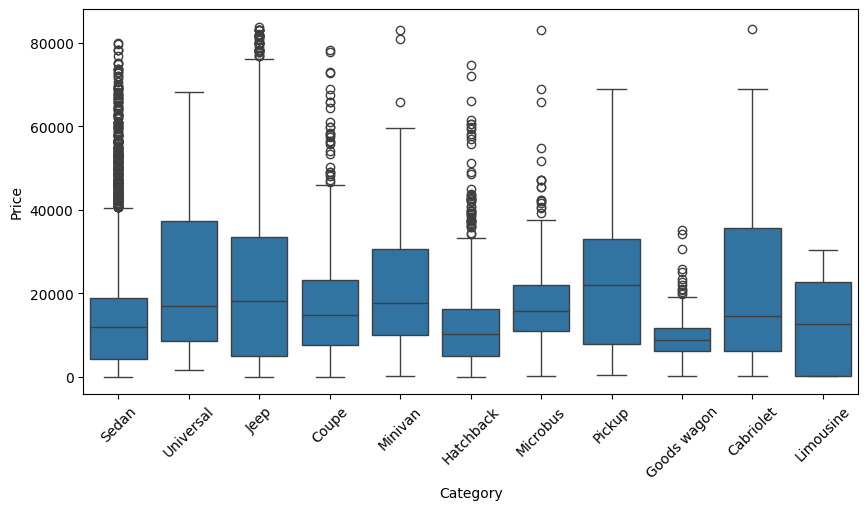

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Category', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

# Price Distribution by Fuel Type

C:\Users\Sameh\AppData\Local\Temp\ipykernel_11980\3916503187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel type', y='Price', palette='Set2')


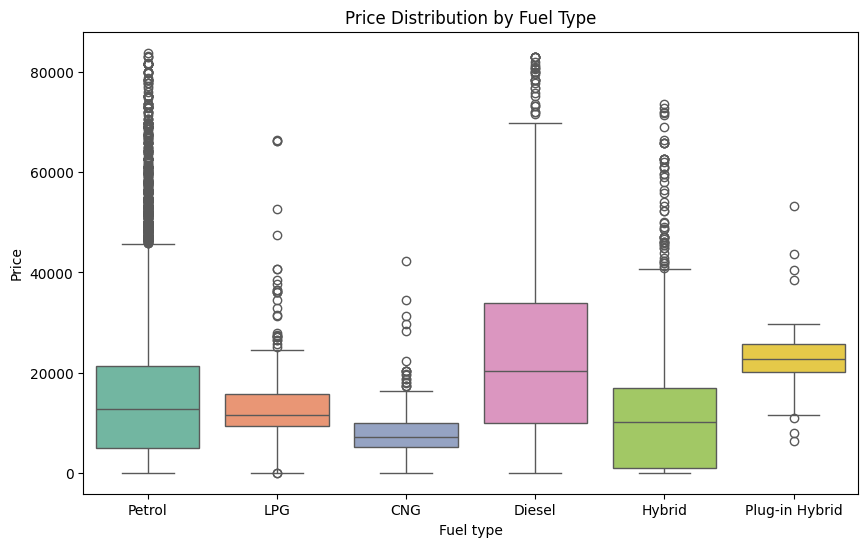

In [25]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel type', y='Price', palette='Set2')
plt.title('Price Distribution by Fuel Type')
plt.show()

# CORRELATION MATRIX

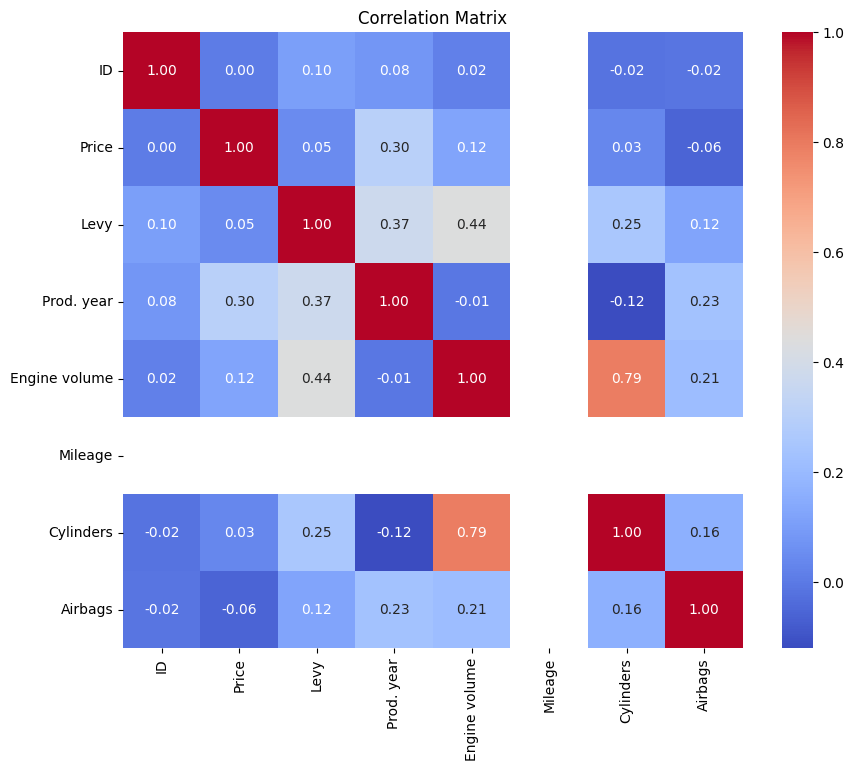

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#  Exploratory Data Analysis (EDA) Summary & Insights

After performing a comprehensive analysis on the Car Price dataset, here are the key findings:

### 1. Target Variable Analysis (Price)
* Outliers: The initial price distribution showed extreme outliers (very expensive cars). Using the IQR method, we successfully cleaned the data, making the distribution more realistic for modeling.
* Skewness: The price was highly right-skewed. Applying a Log Transformation (as suggested in the NYC project) helped normalize the distribution, which will improve our model performance.

### 2. Numerical Features Insights
* Year vs. Price: There is a strong positive correlation between the manufacturing year and the price. Newer models (2020-2024) significantly command higher prices.
* Mileage: Most cars in our dataset are within a reasonable mileage range, but we noticed that as mileage increases, the car price tends to decrease (Negative Correlation).

### 3. Categorical Features Insights
* Fuel Type: Gasoline and Diesel are the most common, but we observed that Hybrid/Electric cars often have a higher median price.
* Accident History: Cars with "None reported" accidents maintain a much higher resale value compared to those with reported accidents.
* Transmission: Automatic transmission is more dominant in the dataset and generally associated with higher-priced modern vehicles.

### 4. Correlation Analysis
* The Heatmap confirms that year and engine_size are the most influential numerical features affecting the price.
* We filtered the dataset to include only numerical types to ensure a proper correlation matrix.

---
Conclusion: The data is now clean, normalized, and ready for the Feature Engineering and Modeling phase.

# preprocessing

# Handling missing values

In [27]:
df.dropna(subset=['Levy','Mileage','Color'])

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags


In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
df.dropna(inplace=True)

In [62]:
df['Prod. year']

0        48
1        43
2        38
3        27
4        11
         ..
15784    46
15785    46
15786    41
15787    31
15788    20
Name: Prod. year, Length: 15256, dtype: int64

In [63]:
df['car_age'] = 2026 - df['Prod. year']
df


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,car_age
0,3219,1036,465,20,186,48,10,1,4,16,0,9,0,1,1,0,1,11,1978
1,729,1412,349,15,868,43,10,1,3,7,0,9,0,1,1,0,4,3,1983
2,10198,1088,440,13,717,38,10,1,4,9,0,9,0,1,1,0,8,11,1988
3,14586,847,0,53,1036,27,2,0,4,55,0,9,1,1,1,0,1,3,1999
4,8363,1908,440,27,453,11,10,0,4,55,0,9,1,2,1,0,8,0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15784,8923,476,407,46,486,46,5,1,4,7,0,9,0,1,1,0,3,3,1980
15785,7385,1434,304,50,669,46,10,1,2,17,0,9,0,1,1,0,6,11,1980
15786,7344,1313,415,34,352,41,5,1,1,55,0,11,0,0,1,0,6,0,1985
15787,3029,313,0,34,1117,31,10,1,4,17,0,11,2,2,1,1,6,11,1995


# Prepare data for modeling

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


X = df.drop(['Price', 'ID'], axis=1, errors='ignore') 
Y = df['Price'] 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

robust_scaler = RobustScaler()

X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

print(" Data is ready with Robust Scaling and Outliers included!")

 Data is ready with Robust Scaling and Outliers included!


# Apply Linear Rgression on the model

In [45]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled , Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Testing linear regression model

In [46]:
from sklearn.metrics import mean_squared_error ,r2_score

Y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(Y_test ,Y_pred )
rmse = np.sqrt(mse)
r2 = r2_score(Y_test , Y_pred)
print(f"MSE : ", mse)
print(f"RMSE : ", rmse)
print(f"R² : ", r2)

MSE :  387654.4389422009
RMSE :  622.6190158854779
R² :  0.03996269022491272


In [47]:
df['Price'].describe()

count    15256.000000
mean       940.513634
std        640.569359
min          0.000000
25%        366.000000
50%        854.000000
75%       1523.250000
max       1998.000000
Name: Price, dtype: float64

Linear Regresion insight  
mse is off by 387654 Rmse is off by 622 unit  
Error is quite high meaning our Linear Regression is not very accurate for this dataset yet , may catogrical data like brand or condition affected price much more

# Visual inspection of liner regresion model results

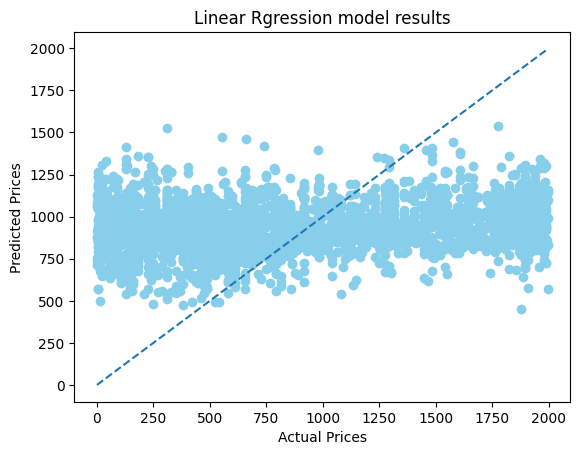

In [48]:
plt.scatter(Y_test , Y_pred, color ='skyblue')
plt.title('Linear Rgression model results')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val , max_val] , [min_val , max_val] , label ='line' , linestyle='--')


plt.show()

# Decision Tree Regressor model

In [49]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled , Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [51]:
Y_pred = dt_model.predict(X_test_scaled)
mse = mean_squared_error(Y_test , Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test , Y_pred)
print(f"MSE : ", mse)
print(f"RMSE : ", rmse)
print(f"R² : ", r2)

MSE :  346935.2428538504
RMSE :  589.0120905837591
R² :  0.14080494441277946


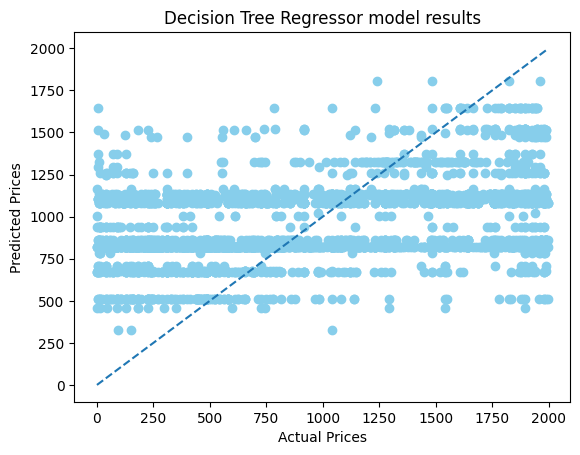

In [52]:
plt.scatter(Y_test , Y_pred , color = 'skyblue')

plt.title('Decision Tree Regressor model results')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val , max_val] , [min_val , max_val] , label ='line' , linestyle='--')

plt.show()

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
g_model = GradientBoostingRegressor()
g_model.fit(X_train_scaled , Y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [54]:
Y_pred = g_model.predict(X_test_scaled)
mse = mean_squared_error(Y_test , Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test , Y_pred)
print(f"MSE : ", mse)
print(f"RMSE : ", rmse)
print(f"R² : ", r2)

MSE :  314432.7627832877
RMSE :  560.7430452384476
R² :  0.22129826628239924


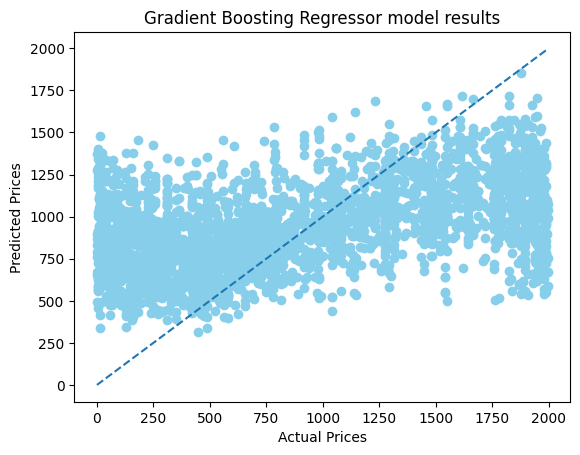

In [56]:
plt.scatter(Y_test , Y_pred , color = 'skyblue')

plt.title('Gradient Boosting Regressor model results')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
plt.plot([min_val , max_val] , [min_val , max_val] , label ='line' , linestyle='--')

plt.show()